# Driver Drowsiness Detection: A CNN and Transfer Learning Comparison

***

## 1. Problem Statement

> **About the problem:** <br>
> Driver fatigue is one of the leading contributing factors to road traffic accidents worldwide. Unlike alcohol or speeding, drowsiness is difficult for drivers to self-monitor in real time, making automated detection systems a practical safety intervention. Camera-based monitoring of the driver's face - specifically eye state - offers a non-intrusive way to flag early signs of fatigue before a critical lapse in attention occurs.

> **Research Problem:** <br>
> This project investigates whether a convolutional neural network (CNN) can reliably classify a driver's facial image as *Drowsy* or *Non-Drowsy*, and whether a pretrained (transfer learning) model offers a meaningful improvement over a CNN trained from scratch on a moderately sized, domain-specific dataset.

> **Objectives:**
>
> 1. Load, clean, and explore the Driver Drowsiness Dataset (DDD).
> 2. Split the data at the **subject level** (not the image level) into train/validation/test sets, to prevent data leakage between frames of the same person.
> 3. Design and train a baseline CNN architecture from scratch.
> 4. Fine-tune a pretrained MobileNetV2 model via transfer learning on the same data.
> 5. Evaluate and compare both models using standard classification metrics.
> 6. Compare the obtained results against findings reported in prior research on driver drowsiness detection.

> **Research Questions:**
>
> 1. Can a CNN trained from scratch achieve reliable drowsiness classification on the DDD dataset?
> 2. Does transfer learning (MobileNetV2) outperform a custom-built CNN on this task, and by how much?
> 3. How do the obtained results compare to accuracy figures reported in previous drowsiness-detection studies?

***

## 2. Related Work

> Several recent studies have applied machine learning and deep learning techniques to driver drowsiness detection using facial and behavioral features:
>
> - **Essahraui et al. (2025)** conducted a systematic comparison of ML (KNN, SVM, Decision Tree, Random Forest) and CV models (CNN, YOLOv5, YOLOv8, Faster R-CNN) across three benchmark datasets - NTHU-DDD, YawDD, and UTA-RLDD. Their custom CNN achieved a test accuracy of **99.97%** on UTA-RLDD and **98.22%** on NTHU-DDD, while KNN was the strongest ML classifier at **98.89%** on UTA-RLDD. [Sensors 2025, 25, 812](https://doi.org/10.3390/s25030812)
>
> - **Zaman, Chatterjee & Sharma** developed a real-time drowsiness detection system using a deep CNN combined with OpenCV for facial landmark extraction (eye closure, yawning). Their model achieved **99.6%** accuracy on the NTHU-DDD dataset and **97%** on the Yawn-Eye-Dataset. [arXiv:2511.12438](https://arxiv.org/pdf/2511.12438)
>
> - **Majeed et al. (2023)** proposed a custom 15-layer CNN for drowsiness detection using the YawDD dataset, extracting the Mouth Aspect Ratio (MAR) via the Dlib library. They compared their CNN with and without data augmentation, reporting a best test accuracy of **96.69%** without augmentation - notably finding that augmentation slightly *reduced* accuracy while improving generalization. [Sensors 2023, 23, 8741](https://doi.org/10.3390/s23218741)
>
> These studies consistently show that CNN-based approaches outperform classical ML methods, and that transfer learning / architectural depth trade off against dataset size and computational cost. This project builds on these findings by directly comparing a custom CNN against a transfer learning model (MobileNetV2) on the DDD dataset, and revisits these reported accuracies in the Discussion section.

***

## 3. Dataset Description

> **Source:** Driver Drowsiness Dataset (DDD)
> * **Provider:** Kaggle, uploaded by Ismail Nasri
> * **Link:** [kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd)
> * **Format:** PNG images, organized into two class folders
> * **Size:** 41,790 images total

| Folder | Class | Label | Naming convention |
| :---: | :---: | :---: | :---: |
| `Drowsy/` | Drowsy | 1 | Uppercase letter + sequential number (e.g. `A0001.png`) |
| `Non Drowsy/` | Non-Drowsy | 0 | Lowercase letter + sequential number (e.g. `a0001.png`) |


> **Subject encoding:** <br>
> Each leading letter in the filename identifies a distinct subject (person / recording session). This is important for the train/val/test split: images from the same subject must not appear in more than one split, or the model could learn to recognize individual faces rather than genuine drowsiness cues.

***

## 4. Imports and Setup

In [1]:
import sys
sys.path.append('src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***

## 5. Data Loading and Cleaning

The dataset is organized into two class folders (`Drowsy` and `Non Drowsy`), with each filename encoding a subject identifier as a leading letter followed by a sequential frame number. The `build_file_index()` function (defined in `src/data_utils.py`) walks this folder structure and builds a single DataFrame indexing every image, its class label, and its subject id - this indexing step is what makes the later subject-level split possible.

In [2]:
from data_utils import build_file_index

raw_dataset_directory = "data/raw/Driver Drowsiness Dataset (DDD)"
drowsiness_dataset_df = build_file_index(raw_dataset_directory)

print(f"Total images indexed: {drowsiness_dataset_df.shape[0]}")
drowsiness_dataset_df.head()

Total images indexed: 41793


,image_filepath,drowsiness_label,subject_id
0,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
1,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
2,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
3,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
4,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A


In [3]:
print("Missing values per column:")
print(drowsiness_dataset_df.isna().sum())

print(f"\nDuplicate rows: {drowsiness_dataset_df.duplicated().sum()}")

print(f"\nUnique subjects: {drowsiness_dataset_df['subject_id'].nunique()}")
print(f"Class distribution:\n{drowsiness_dataset_df['drowsiness_label'].value_counts()}")

Missing values per column:
image_filepath      0
drowsiness_label    0
subject_id          0
dtype: int64

Duplicate rows: 0

Unique subjects: 54
Class distribution:
drowsiness_label
1    22348
0    19445
Name: count, dtype: int64


### Interpretation

> * The file index was built by recursively scanning the raw dataset directory and extracting the drowsiness label and subject ID directly from each image's file path and naming convention. The resulting `drowsiness_dataset_df` contains **41,793 total images**, closely matching the ~41,790 images reported in the original Kaggle dataset description, which supports that the indexing logic correctly captured the expected dataset size.
> * A data quality check shows **zero missing values** across all three columns (`image_filepath`, `drowsiness_label`, `subject_id`) and **zero duplicate rows**, indicating a clean and well-formed index with no repeated entries at the dataframe level.
> * The dataset spans **54 unique subjects**, which provides a sufficient number of individuals for a subject-level train/validation/test split - ensuring that images from the same individual do not appear across different splits and helping prevent data leakage and overly optimistic performance metrics.
> * The class distribution is **22,348 drowsy (53.5%)** vs. **19,445 non-drowsy (46.5%)** images. This represents a mild class imbalance (~7 percentage point gap), not severe enough to require resampling techniques at this stage. However, the imbalance will be taken into account when evaluating model performance - precision, recall, F1-score, and per-class performance will be reported separately rather than relying on accuracy alone.

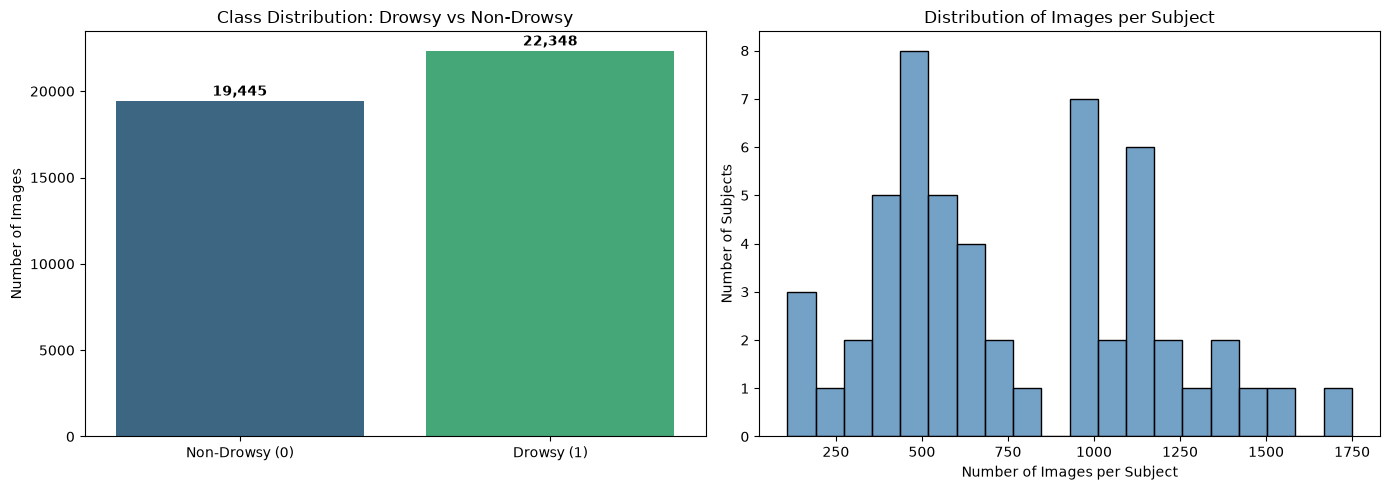

Images per subject - min: 109, max: 1749, mean: 773.9


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts_series = drowsiness_dataset_df['drowsiness_label'].value_counts().sort_index()
class_labels = ['Non-Drowsy (0)', 'Drowsy (1)']

sns.barplot(x=class_labels, y=class_counts_series.values, hue=class_labels, legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution: Drowsy vs Non-Drowsy')
axes[0].set_ylabel('Number of Images')
for index, count_value in enumerate(class_counts_series.values):
    axes[0].text(index, count_value + 300, f'{count_value:,}', ha='center', fontweight='bold')

images_per_subject_series = drowsiness_dataset_df.groupby('subject_id').size().sort_values(ascending=False)
sns.histplot(images_per_subject_series.values, bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Images per Subject')
axes[1].set_xlabel('Number of Images per Subject')
axes[1].set_ylabel('Number of Subjects')

plt.tight_layout()
plt.show()

print(f"Images per subject - min: {images_per_subject_series.min()}, "
      f"max: {images_per_subject_series.max()}, "
      f"mean: {images_per_subject_series.mean():.1f}")

### Interpretation

> * The class distribution bar chart confirms the earlier value counts: **22,348 drowsy** vs. **19,445 non-drowsy** images, a mild ~7 percentage point **class-level imbalance** that does not require resampling.
> * The images-per-subject histogram reveals a **bimodal distribution** rather than a uniform one - subjects cluster into two groups: one around 400–650 images and another around 950–1,150 images, with a visible gap between them. This may indicate that the dataset was collected under different recording conditions, such as different session durations or frame rates per subject, rather than each subject contributing a similar, fixed number of frames.
> * The spread is substantial: images per subject range from a **minimum of 109 to a maximum of 1,749** (a ~16x difference), with a **mean of 773.9**. This confirms a meaningful **subject-level contribution imbalance** (distinct from the mild class-level imbalance above) - a handful of subjects contribute disproportionately more images to the dataset than others.
> * This has a direct implication for the train/validation/test split strategy: a simple random image-level split risks over-representing high-frequency subjects in one partition and under-representing them in another. The planned **subject-level split** (assigning entire subjects to train/val/test rather than individual images) is therefore essential - it prevents both data leakage (same subject's face appearing in train and test) and skewed subject representation across splits.

In [5]:
subject_class_summary_df = drowsiness_dataset_df.groupby('subject_id')['drowsiness_label'].agg(
    total_images='count',
    drowsy_images='sum'
)
subject_class_summary_df['non_drowsy_images'] = (
    subject_class_summary_df['total_images'] - subject_class_summary_df['drowsy_images']
)
subject_class_summary_df['drowsy_ratio'] = (
    subject_class_summary_df['drowsy_images'] / subject_class_summary_df['total_images']
)

print(f"Subjects with ONLY drowsy images: {(subject_class_summary_df['drowsy_ratio'] == 1.0).sum()}")
print(f"Subjects with ONLY non-drowsy images: {(subject_class_summary_df['drowsy_ratio'] == 0.0).sum()}")
print(f"Subjects with BOTH classes present: {((subject_class_summary_df['drowsy_ratio'] > 0) & (subject_class_summary_df['drowsy_ratio'] < 1)).sum()}")

print("\nDrowsy ratio per subject - summary statistics:")
print(subject_class_summary_df['drowsy_ratio'].describe())

subject_class_summary_df.sort_values('total_images', ascending=False).head(10)

Subjects with ONLY drowsy images: 28
Subjects with ONLY non-drowsy images: 26
Subjects with BOTH classes present: 0

Drowsy ratio per subject - summary statistics:
count    54.000000
mean      0.518519
std       0.504349
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: drowsy_ratio, dtype: float64


,total_images,drowsy_images,non_drowsy_images,drowsy_ratio
subject_id,,,,
Drowsy_X,1749,1749,0,1.0
Drowsy_ZB,1551,1551,0,1.0
Non Drowsy_y,1500,0,1500,0.0
Drowsy_A,1411,1411,0,1.0
Drowsy_ZC,1346,1346,0,1.0
Non Drowsy_zc,1288,0,1288,0.0
Non Drowsy_a,1252,0,1252,0.0
Non Drowsy_zb,1237,0,1237,0.0
Drowsy_W,1162,1162,0,1.0


### Interpretation

> * Every subject contributes images from exactly one class only - 28 subjects are exclusively drowsy and 26 are exclusively non-drowsy, with zero subjects containing both classes. The `drowsy_ratio` distribution is therefore fully separated (25th percentile = 0.0, 50th percentile = 1.0, 75th percentile = 1.0), confirming that subjects belong entirely to one class rather than having a mixture of both.
> * This means `subject_id` perfectly determines `drowsiness_label` in this dataset - each subject is associated with either the drowsy or the non-drowsy class, rather than both. This suggests that the class assignment was made at the subject/recording-session level rather than at the individual-frame level. This is also reflected in the subject naming convention (`Drowsy_X`, `Non Drowsy_y`, etc.), which appears to encode the class in the subject identifier.
> * This finding is consistent with the earlier observations about the images-per-subject distribution: the dataset consists of two distinct subject pools, one drowsy-only and one non-drowsy-only. The mild class-level image imbalance (53.5% drowsy vs. 46.5% non-drowsy) is therefore influenced by both the number of subjects in each class (28 vs. 26) and the different numbers of images contributed by individual subjects.
> * The critical modeling implication: since class is fully determined by subject, a subject-level split is essential for evaluating generalization to unseen individuals. Any image-level random split would place images from the same subject in both train and test, potentially allowing the model to exploit subject-specific characteristics such as facial appearance, lighting, camera angle, or background instead of learning generalizable drowsiness cues. Reported test performance under an image-level split could therefore be artificially inflated and would not reliably reflect performance on unseen subjects. When creating the subject-level split, the drowsy and non-drowsy subject groups should also be represented appropriately across train, validation, and test sets.

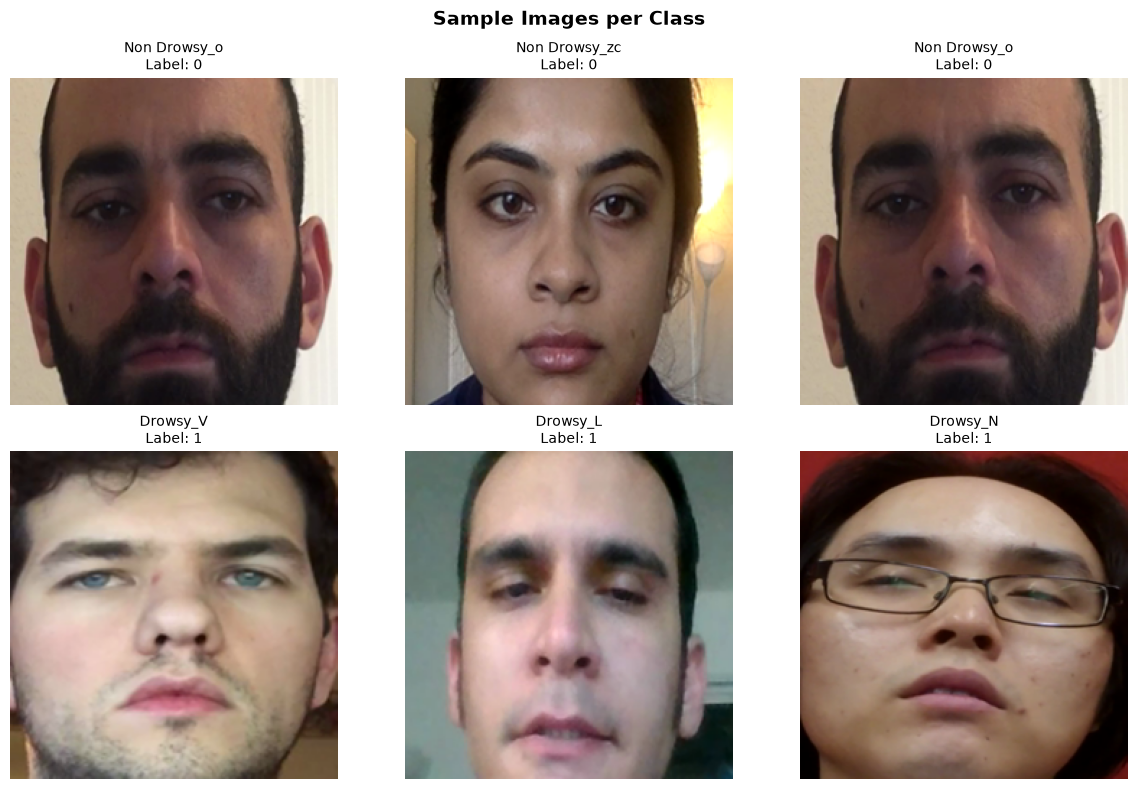

In [6]:
sample_images_per_class = 3
fig, axes = plt.subplots(2, sample_images_per_class, figsize=(12, 8))

for class_index, class_label in enumerate([0, 1]):
    class_subset_df = drowsiness_dataset_df[
        drowsiness_dataset_df['drowsiness_label'] == class_label
    ]
    sampled_rows_df = class_subset_df.sample(n=sample_images_per_class, random_state=42)

    for column_index, (_, row) in enumerate(sampled_rows_df.iterrows()):
        image = plt.imread(row['image_filepath'])
        axes[class_index, column_index].imshow(image)
        axes[class_index, column_index].set_title(
            f"{row['subject_id']}\nLabel: {row['drowsiness_label']}", fontsize=10
        )
        axes[class_index, column_index].axis('off')

fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

> * Visual inspection of the sampled images shows that the labels are consistent with the visible drowsiness state: non-drowsy samples generally show subjects with open eyes and an alert, forward-facing appearance, while drowsy samples show closed or near-closed eyes and drooping eyelids. This provides a visual sanity check that the two classes represent distinguishable drowsiness states.
> * The sampled images also show variation in facial appearance, facial hair, eyewear (one drowsy subject wears glasses), and background/lighting conditions (e.g. the red-tinted background in one drowsy sample vs. more neutral backgrounds elsewhere). This suggests that the dataset contains some variation in appearance and recording conditions rather than a completely uniform visual setup.
> * One subject (`Non Drowsy_o`) appears twice in the 3-image non-drowsy sample, indicating that the sampling was performed at the image level rather than selecting unique subjects. This is not an error and is expected when multiple images from the same subject are available. However, this example also highlights why image-level sampling and splitting must be distinguished from subject-level splitting: multiple images from the same individual can easily appear in the same sample or, more importantly, across different dataset splits if subjects are not explicitly kept together.
> * Overall, the visual inspection provides a useful sanity check on the dataset labels and shows that drowsiness-related visual cues are present in the images. However, these examples alone are not sufficient to assess the generalization of the dataset; the earlier subject-level analysis and split strategy remain essential for preventing subject overlap between train, validation, and test sets.

In [7]:
from data_utils import subject_level_split, print_split_summary

train_images_df, val_images_df, test_images_df = subject_level_split(drowsiness_dataset_df)
print_split_summary(train_images_df, val_images_df, test_images_df)

Train | images:  29290 | subjects:  31 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.535, 0: 0.465}
Val   | images:   6165 | subjects:  11 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.539, 0: 0.461}
Test  | images:   6338 | subjects:  12 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.528, 0: 0.472}


### Interpretation

> * The subject-level split allocated 31 subjects (29,290 images, 70.0%) to Train, 11 subjects (6,165 images, 14.8%) to Validation, and 12 subjects (6,338 images, 15.2%) to Test - closely matching the target 70/15/15 ratio.
> * Critically, the class balance is now nearly identical across all three splits: 53.5% drowsy in Train, 53.9% in Validation, 52.8% in Test - a spread of only ~1.1 percentage points. This indicates that the split successfully distributes the two classes consistently across the three partitions while keeping subjects separated.
> * This provides a suitable basis for training and evaluation: each partition has a class composition close to that of the full dataset (~53.5% drowsy / ~46.5% non-drowsy), reducing the risk that differences in model performance are caused by substantially uneven class representation between the splits. However, performance differences may still reflect differences in subject characteristics and difficulty across the partitions.
> * As established earlier, keeping entire subjects within a single partition is essential for preventing subject-level data leakage. Assuming the `_assert_no_subject_overlap()` validation passes, the absence of subject overlap, combined with the consistent class distribution, provides a methodologically sound foundation for Section 6 (Preprocessing) and Section 7 (Modeling).

***

## 6. Preprocessing

Before training, the raw images need to be converted into a format suitable for a convolutional neural network:

- **Resizing** - all images are resized to a fixed target size (145×145 px), since a CNN requires a consistent input shape across all samples, while the raw DDD images may vary slightly in dimensions.
- **Grayscale conversion** - the images are loaded in grayscale rather than RGB. Drowsiness cues (eye closure, eyelid droop) are structural/shape-based rather than color-based, so grayscale reduces input dimensionality and computational cost without discarding relevant information.
- **Normalization** - pixel values are rescaled from the [0, 255] range to [0, 1] by dividing by 255. This keeps input values in a small, consistent range, which helps gradient-based optimization converge faster and more stably.
- **Data augmentation (training set only)** - random rotation, zoom, brightness shifts, and small width/height shifts are applied to the training images on the fly during training. This artificially increases the diversity of the training data and reduces overfitting, which is particularly important given the limited number of unique subjects (54) in this dataset. Horizontal flipping is intentionally **not** used, since face orientation (e.g. head tilt direction) may itself carry information relevant to drowsiness.
- **No augmentation on validation/test sets** - these sets are only rescaled, never augmented, since they must reflect realistic, unmodified data to give a reliable estimate of model performance.

This preprocessing pipeline is implemented in `build_data_generators()` in `data_utils.py`, which returns three Keras `ImageDataGenerator` flows (train, validation, test) built directly from the subject-level split created in Section 5.

### Key Formulas

* <u>Min-Max Normalization</u>
1. *Definition* -> a data preprocessing technique that rescales values so that all numeric values fall within a specific, bounded range - typically [0, 1] - by scaling relative to the minimum and maximum of the original range.
2. *Formula*:
$$ x_{normalized} = \frac{x - x_{min}}{x_{max} - x_{min}} $$

    -> $x$ is the original data point value; <br>
    -> $x_{min}$ is the minimum value across the entire dataset feature; <br>
    -> $x_{max}$ is the maximum value across the entire dataset feature; <br>
    -> $x_{normalized}$ is the newly scaled value (between 0 and 1).

* <u>Normalization applied to 8-bit pixel intensities</u>
1. *Definition* -> the specific case of min-max normalization used for image pixel values, where the minimum and maximum are fixed and known in advance (0 and 255 for 8-bit images), rather than computed from the data.
2. *Formula*:
$$ x_{normalized} = \frac{x}{255} $$

    -> $x$ is the original pixel intensity, in the range [0, 255]; <br>
    -> dividing by the fixed maximum (255) rescales every pixel to the [0, 1] range, which helps gradient-based optimizers (e.g. Adam, SGD) converge faster and more stably during training.

In [8]:
from data_utils import build_data_generators

train_generator, val_generator, test_generator = build_data_generators(
    train_images_df.copy(), val_images_df.copy(), test_images_df.copy()
)

C:\Users\djuli\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.1)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Found 29290 validated image filenames belonging to 2 classes.
Found 6165 validated image filenames belonging to 2 classes.
Found 6338 validated image filenames belonging to 2 classes.


### Interpretation

> * The three `ImageDataGenerator` flows were built successfully, confirming **29,290 training images**, **6,165 validation images**, and **6,338 test images** - matching exactly the split sizes established in Section 5. Each generator correctly identified **2 classes** (Drowsy / Non Drowsy) from the `drowsiness_label` column.
> * As designed, the training generator applies on-the-fly augmentation (rotation, zoom, brightness, width/height shifts) and shuffles data each epoch, while the validation and test generators only rescale pixel values and preserve the original image order (`shuffle=False`). This ordering is important later because it allows predictions to be correctly matched with their corresponding true labels when generating the confusion matrix and classification report in Section 8.

Found 6 validated image filenames belonging to 2 classes.


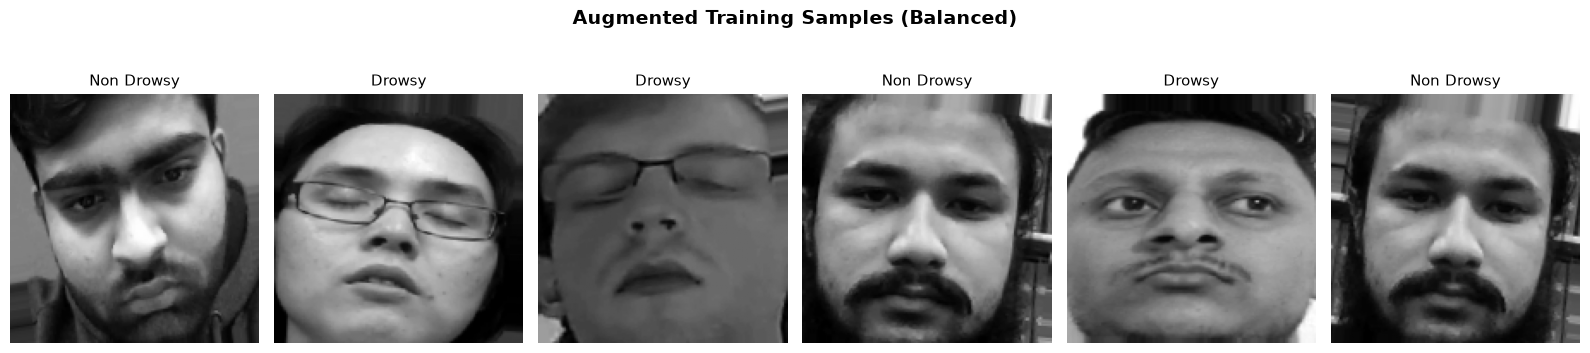

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sample_drowsy_df = train_images_df[train_images_df['drowsiness_label'] == 1].sample(n=3)
sample_non_drowsy_df = train_images_df[train_images_df['drowsiness_label'] == 0].sample(n=3)
balanced_sample_df = pd.concat([sample_drowsy_df, sample_non_drowsy_df]).sample(frac=1).reset_index(drop=True)
balanced_sample_df['drowsiness_label'] = balanced_sample_df['drowsiness_label'].astype(str)

demo_augmenter = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    width_shift_range=0.05,
    height_shift_range=0.05,
)

demo_generator = demo_augmenter.flow_from_dataframe(
    balanced_sample_df,
    x_col='image_filepath',
    y_col='drowsiness_label',
    target_size=(145, 145),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=6,
    shuffle=False,
)

sample_batch_images, sample_batch_labels = next(demo_generator)

fig, axes = plt.subplots(1, 6, figsize=(16, 4))
for i in range(6):
    axes[i].imshow(sample_batch_images[i].squeeze(), cmap='gray')
    label_text = 'Drowsy' if sample_batch_labels[i] == 1 else 'Non Drowsy'
    axes[i].set_title(label_text, fontsize=11)
    axes[i].axis('off')

fig.suptitle('Augmented Training Samples (Balanced)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

> * The augmented training samples provide a visual check that the preprocessing pipeline is producing usable model inputs: the images are displayed in grayscale, facial regions remain clearly visible, and the drowsiness-relevant features (particularly eye and eyelid appearance) are preserved after preprocessing and augmentation.
> * The samples show visible variation between executions, consistent with the application of on-the-fly augmentation transformations such as rotation, shifts, zoom, and brightness changes. The transformations do not appear to distort the facial features to the point of obscuring the relevant visual cues.
> * The sample was constructed to explicitly draw 3 Drowsy and 3 Non-Drowsy images (rather than relying on a single random batch from the full shuffled generator), so both classes are always represented in the visualization. The specific subjects and augmentation transformations shown will still vary between executions, since the underlying images and augmentation parameters are sampled randomly each time - only the class balance of the displayed batch is fixed.
> * A closer look at individual samples can also illustrate a potential source of label noise inherent to this dataset: since labels are assigned at the subject/recording-session level rather than per individual frame (as established in Section 5), not every frame within a "drowsy" session necessarily shows visibly closed or drooping eyes, while some frames within a "non-drowsy" session may contain blinking or a downward glance that visually resembles drowsiness. This session-level labeling is a limitation of the dataset itself rather than an error in the preprocessing pipeline, and it means that the model may be exposed to some frame-level label noise during training.

***
## 7. Modeling

Two modeling approaches are built and compared, in line with the project's goal of contrasting a from-scratch approach with a transfer learning approach:

- **Custom CNN (trained from scratch)** - a convolutional neural network designed specifically for this task, with no pretrained weights. This establishes a baseline that learns drowsiness-relevant features purely from the DDD dataset itself.
- **Transfer learning (MobileNetV2)** - a CNN pretrained on ImageNet (1.4M images, 1000 classes), with its convolutional base reused and a new classification head trained on top for this binary task. Transfer learning is expected to converge faster and generalize better with limited data, since the pretrained base has already learned general-purpose visual features (edges, textures, shapes) that transfer well to a new image classification task.

Both models are trained using the same train/validation split (Section 5) and the same preprocessing pipeline (Section 6), so that differences in their final performance can be attributed to the modeling approach itself rather than to differences in the data they saw.

The model-building logic is implemented in `models.py`, kept separate from the notebook for the same reason as `data_utils.py` - reusability and cleaner separation between data pipeline, model architecture, and the analysis/narrative presented in the notebook.

### Key Formulas

* <u>2D Convolution Operation</u>
1. *Definition* -> the core operation of a CNN, defining a 2D discrete convolution (or cross-correlation) between an input image/feature map and a small filter (kernel). Each output value at position $(i,j)$ is computed as a weighted sum of neighboring input values, producing a feature map that highlights patterns such as edges, textures, or shapes. In practice, deep learning frameworks (PyTorch, TensorFlow/Keras) implement this as cross-correlation (no kernel flipping) rather than true mathematical convolution, though it is conventionally still called "convolution" in the literature, since the distinction does not affect what the network is able to learn.
2. *Formula*:
$$ Y(i,j) = \sum_{m} \sum_{n} X(i+m,\, j+n) \cdot K(m,n) $$

    -> $Y(i,j)$ is the output value at row $i$ and column $j$ of the resulting feature map; <br>
    -> $X(i+m, j+n)$ is the input data values around the target position $(i,j)$; <br>
    -> $K(m,n)$ is the kernel weights (filter values) at offset $(m,n)$; <br>
    -> $\sum_m \sum_n$ sums the weighted products over all rows and columns of the kernel.

* <u>ReLU Activation Function</u>
1. *Definition* -> a non-linear activation function that outputs the input directly if it is positive and zero otherwise, applied after each convolution to introduce non-linearity into the network. It is a default choice in many CNN architectures due to its simplicity and computational efficiency, and it reduces the vanishing gradient problem compared to older activations like sigmoid/tanh in deep layers.
2. *Formula*:
$$ f(x) = \max(0, x) $$

    -> $x$ is the input to the neuron (e.g. the output of a convolution before activation); <br>
    -> the function returns $x$ if $x$ is greater than 0; <br>
    -> if $x$ is less than or equal to 0, the function returns 0.

* <u>Sigmoid Activation Function</u>
1. *Definition* -> maps any real number to a value strictly between 0 and 1, creating a characteristic S-shaped curve. Used in the final output layer for binary classification, it converts the network's raw output into a probability - specifically, the predicted probability of the "Drowsy" class.
2. *Formula*:
$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

    -> $x$ is the input to the output neuron (the final layer's raw, unactivated score, also called the logit); <br>
    -> $\sigma(x)$ is the resulting probability, used to decide the predicted class (typically Drowsy if $\sigma(x) \geq 0.5$); <br>
    -> at $x = 0$, the output is exactly 0.5, the midpoint of the curve.

* <u>Binary Cross-Entropy Loss</u>
1. *Definition* -> a loss function used in binary classification problems, quantifying the difference between the actual class labels (0 or 1) and the predicted probabilities output by the model. The lower the binary cross-entropy value, the better the model's predictions align with the true labels; it penalizes confident wrong predictions much more heavily than uncertain ones.
2. *Formula*:
$$ BCE = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right] $$

    -> $N$ is the number of observations; <br>
    -> $y_i$ is the actual binary label (0 or 1) of the $i$-th observation; <br>
    -> $p_i$ is the predicted probability of the $i$-th observation being in class 1 (the output of the sigmoid).

* <u>Max Pooling</u>
1. *Definition* -> a downsampling operation applied after convolution, which divides the feature map into small regions and keeps only the maximum value from each region. This reduces the spatial dimensions (and therefore the number of parameters and computation in later layers), while retaining the strongest, most relevant activations and making the learned features more robust to small shifts in position.
2. *Formula (output value)*:
$$ f(x) = \max(x_i) $$

    -> $x_i$ is the set of values inside the pooling window at a given position; <br>
    -> $f(x)$ is the single output value for that window - the largest activation within it.
3. *Formula (output dimensions)*, for an input feature map of size $n_h \times n_w \times n_c$:
$$ \left\lfloor \frac{n_h - f}{s} \right\rfloor + 1 \;\times\; \left\lfloor \frac{n_w - f}{s} \right\rfloor + 1 \;\times\; n_c $$

    -> $n_h$, $n_w$ are the input height and width; <br>
    -> $n_c$ is the number of channels (unchanged by pooling); <br>
    -> $f$ is the filter (pooling window) size; <br>
    -> $s$ is the stride length.

* <u>Gradient Descent Weight Update (Backpropagation)</u>
1. *Definition* -> the rule used to adjust each weight in the network during training, in the direction that reduces the loss (cost). Backpropagation computes the gradient of the cost with respect to each weight (via the chain rule, propagating error backward through the network), and gradient descent uses that gradient to update the weight.
2. *Formula*:
$$ W_{new} = W_{old} - \alpha \frac{\partial J}{\partial W_{old}} $$

    -> $W_{old}$ is the weight's current value; <br>
    -> $\alpha$ is the learning rate, controlling the size of each update step; <br>
    -> $\dfrac{\partial J}{\partial W_{old}}$ is the gradient of the cost function $J$ with respect to that weight (computed via backpropagation) - it indicates the direction of steepest increase in the loss, so the weight is updated in the opposite direction; <br>
    -> $W_{new}$ is the updated weight after this training step.

* <u>Depthwise Separable Convolution (MobileNetV2)</u>
1. *Definition* -> the core building block of MobileNetV2, which factorizes a standard convolution into two cheaper steps: a depthwise convolution (a single filter applied per input channel, capturing spatial patterns) followed by a pointwise (1×1) convolution (combining the channels together). This factorization is what allows MobileNetV2 to reach accuracy comparable to larger networks with far fewer parameters and less computation, making it well suited for transfer learning under limited data/compute.
2. *Complexity comparison*:

    | Type of Convolution | Complexity (multiplications) |
    |---|---|
    | Standard | $N \times D_P^2 \times D_G^2 \times M$ |
    | Depthwise separable | $M \times D_P^2 \times (D_K^2 + N)$ |

    -> $M$ is the number of input channels; <br>
    -> $N$ is the number of output channels; <br>
    -> $D_P$ is the spatial size of the output feature map; <br>
    -> $D_G$ / $D_K$ is the spatial size of the convolution kernel (e.g. 3 for a 3×3 kernel).

3. *Reduction ratio*, taking the ratio of depthwise separable complexity to standard complexity:
$$ R = \frac{\text{Complexity of depthwise separable convolution}}{\text{Complexity of standard convolution}} = \frac{1}{N} + \frac{1}{D_K^2} $$

    -> for example, with $N = 100$ output channels and a $D_K = 3$ (3×3) kernel: $R = \frac{1}{100} + \frac{1}{9} \approx 0.121$, meaning the depthwise separable convolution requires roughly **8× fewer multiplications** than the equivalent standard convolution - this is the core efficiency gain that makes MobileNetV2 practical for transfer learning here.

* <u>Batch Normalization</u>
1. *Definition* -> normalizes the activations of a layer across each mini-batch during training (zero mean, unit variance), then rescales and shifts the result using two learnable parameters. This stabilizes and speeds up training by reducing internal covariate shift (the tendency of layer input distributions to shift as earlier layers' weights update), and has a mild regularizing effect that can reduce the need for other regularization.
2. *Formula*:
$$ \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y_i = \gamma \hat{x}_i + \beta $$

    -> $x_i$ is the pre-activation value for a given unit, before normalization; <br>
    -> $\mu_B$ and $\sigma_B^2$ are the mean and variance computed across the current mini-batch; <br>
    -> $\epsilon$ is a small constant added for numerical stability (avoiding division by zero); <br>
    -> $\gamma$ and $\beta$ are learnable parameters that let the network rescale and shift the normalized output, so normalization does not force every layer to have exactly zero mean/unit variance if that is not optimal; <br>
    -> $y_i$ is the final output passed to the next layer (the activation function, in our case ReLU).

### 7.1 Custom CNN - Architecture

The custom CNN follows a standard convolutional design: three convolutional blocks of increasing depth (32 -> 64 -> 128 filters), each followed by max pooling to progressively reduce spatial dimensions, then a `GlobalAveragePooling2D` layer (chosen over `Flatten` to keep the parameter count low, see Interpretation below) before the dense classification head.

Batch normalization is applied after each convolution (before the ReLU activation), which stabilizes and speeds up training by normalizing layer activations within each mini-batch - a standard technique in modern CNN design.

In [10]:
from models import build_custom_cnn

custom_cnn_model = build_custom_cnn()
custom_cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 160, 160, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 160, 160, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 160, 160, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 80, 80, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 80, 80, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 80, 80, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 80, 80, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 40, 40, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 40, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 40, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 40, 40, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

### Interpretation

> * The model summary confirms the intended architecture: three convolutional blocks (Conv2D -> BatchNormalization -> ReLU -> MaxPooling, 32 -> 64 -> 128 filters) followed by `GlobalAveragePooling2D()`, which condenses the final 20×20×128 feature map into just 128 values (one averaged activation per feature map), before the `Dense(128)` classification head. This results in a compact model with 110,209 total parameters and a model size of only 430.50 KB.
> * `GlobalAveragePooling2D()` was deliberately chosen over the more traditional `Flatten()` layer: flattening the 20×20×128 feature map directly would produce a 51,200-dimensional vector, which would require a Dense layer with 6,553,728 parameters alone - a substantial increase in model complexity and potentially greater overfitting risk, particularly given the dataset's subject-level structure and the limited number of unique subjects (54). Global average pooling avoids this by summarizing each feature map into a single average activation, reducing the influence of precise spatial position while producing a compact representation for the classification head.
> * `BatchNormalization()` is applied after each convolution (before the ReLU activation), adding 896 parameters (128 + 256 + 512 across the three blocks) - four parameters per channel for each of the 32 + 64 + 128 = 224 channels. Of these, half are trainable (the γ/β scale and shift parameters, 448 total) and half are non-trainable (the running mean/variance statistics tracked during training for use at inference time, 448 total). This is why the model now reports 109,761 trainable and 448 non-trainable parameters, rather than being fully trainable as in the version without batch normalization.
> * The total parameter count (110,209) is only marginally higher than the 109,313 seen without batch normalization - the added parameter cost is minimal relative to the potential benefits of more stable training and improved convergence. Whether BatchNormalization improves training stability, convergence, or generalization compared to the non-normalized version will be evaluated later using the training and validation performance.

### 7.2 MobileNetV2 - Architecture

The transfer learning model reuses MobileNetV2's convolutional base (pretrained on ImageNet), with its weights frozen so that only the new classification head is trained initially. This lets the model reuse general-purpose visual features already learned from 1.4M images, rather than learning them from scratch on our much smaller dataset (~42K images, 54 subjects).

In [11]:
from models import build_mobilenetv2_model

mobilenetv2_model = build_mobilenetv2_model()
mobilenetv2_model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 160, 160, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ grayscale_to_rgb (Conv2D)            │ (None, 160, 160, 3)         │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,087 (9.24 MB)

 Trainable params: 164,103 (641.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Interpretation

> * The model summary confirms that MobileNetV2 is configured for a 160×160 input, which is one of the supported input resolutions for the pretrained MobileNetV2 weights. This allows the pretrained weights to be loaded directly for the selected input size, without falling back to a different resolution as in the earlier 145×145 configuration.
> * The `grayscale_to_rgb` layer (a 1x1 `Conv2D`) learns a mapping from the single-channel grayscale input to 3 channels, adding only 6 trainable parameters (3 kernel weights and 3 biases), before the input is passed to the frozen MobileNetV2 base. The base produces a 5×5×1280 feature map, which is then reduced to 1,280 features by `GlobalAveragePooling2D()`.
> * The model has 2,422,087 total parameters, of which only 164,103 are trainable (6.8%) and 2,257,984 are non-trainable (93.2%). This confirms that the MobileNetV2 base is frozen (`freeze_base=True`), so training updates only the newly added layers (`grayscale_to_rgb`, `Dense(128)`, and `Dense(1)`), while the pretrained ImageNet feature extractor remains unchanged.
> * Compared to the custom CNN (110,209 total parameters, 109,761 trainable), MobileNetV2 has roughly 22× more total parameters, but a comparable number of trainable parameters (164,103 vs. 109,761). This means the trainable classification part remains relatively compact, while the much larger pretrained MobileNetV2 base provides learned feature representations. Although the frozen base does not receive gradient updates, it still contributes computational cost during the forward pass for each training batch.

### 7.3 Compiling the Models

Before training, each model needs to be compiled with three components:

- **Optimizer** - Adam is used for both models, a widely used variant of gradient descent that adapts the learning rate per parameter based on past gradients, generally converging faster and more reliably than plain SGD without extensive manual tuning of the learning rate.
- **Loss function** - Binary Cross-Entropy (defined in the Key Formulas above), the standard loss for binary classification, since it directly measures how far the predicted probabilities are from the true 0/1 labels.
- **Metrics** - accuracy is tracked during training as a quick, interpretable signal of progress per epoch. It is not the only metric used to judge the models: precision, recall, F1-score, and the confusion matrix (Section 8) will provide a more complete picture, especially since accuracy alone can be misleading if the class distribution were more imbalanced.

In [12]:
custom_cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenetv2_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Both models compiled successfully.")

Both models compiled successfully.


### 7.4 Callbacks

Two callbacks are used during training to make the process more efficient and reliable:

- **EarlyStopping** - monitors validation loss and stops training if it stops improving for a set number of epochs (patience), restoring the model's best weights afterward. This prevents unnecessary training once the model has stopped generalizing better, and helps guard against overfitting, since validation loss typically starts rising again once the model begins memorizing the training set rather than learning generalizable patterns.
- **ModelCheckpoint** - saves the model's weights to disk whenever validation performance improves, ensuring the best-performing version of each model (not just the one from the final epoch) is preserved and can be reloaded later for evaluation in Section 8.

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_callbacks(model_name: str):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    model_checkpoint = ModelCheckpoint(
        filepath=f'{model_name}_best.keras',
        monitor='val_loss',
        save_best_only=True
    )
    return [early_stopping, model_checkpoint]

custom_cnn_callbacks = build_callbacks('custom_cnn')
mobilenetv2_callbacks = build_callbacks('mobilenetv2')

### 7.5 Training

Both models are trained using the generators built in Section 6, with the callbacks defined above. A relatively small number of epochs is used as an upper bound - `EarlyStopping` is expected to halt training earlier once validation loss stops improving, so the exact number of epochs actually run may be lower than the maximum specified.

Given the dataset size (~29,290 training images) and the lack of GPU acceleration in this environment (training runs on CPU only), the epoch budget and early stopping patience were set conservatively (`epochs=10`, `patience=3`) to keep training time practical, rather than being tuned purely for maximum possible performance. This is a deliberate, documented trade-off given the project's time constraints, not an attempt to shortcut the methodology - EarlyStopping still ensures training stops based on validation performance, not an arbitrary fixed schedule.

In [14]:
custom_cnn_history = custom_cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=custom_cnn_callbacks
)

Epoch 1/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 1071s 1s/step - accuracy: 0.8441 - loss: 0.3566 - val_accuracy: 0.5388 - val_loss: 4.7279
Epoch 2/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 1047s 1s/step - accuracy: 0.9629 - loss: 0.1094 - val_accuracy: 0.4067 - val_loss: 3.1562
Epoch 3/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 1033s 1s/step - accuracy: 0.9815 - loss: 0.0577 - val_accuracy: 0.5569 - val_loss: 3.9527
Epoch 4/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 1528s 2s/step - accuracy: 0.9867 - loss: 0.0417 - val_accuracy: 0.4315 - val_loss: 5.9117
Epoch 5/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 1104s 1s/step - accuracy: 0.9884 - loss: 0.0349 - val_accuracy: 0.4879 - val_loss: 7.9244


In [15]:
mobilenetv2_history = mobilenetv2_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=mobilenetv2_callbacks
)

Epoch 1/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 922s 999ms/step - accuracy: 0.9800 - loss: 0.0587 - val_accuracy: 0.2586 - val_loss: 3.4970
Epoch 2/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 943s 1s/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.2727 - val_loss: 4.0747
Epoch 3/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 986s 1s/step - accuracy: 0.9970 - loss: 0.0095 - val_accuracy: 0.2157 - val_loss: 4.9047
Epoch 4/10
916/916 ━━━━━━━━━━━━━━━━━━━━ 938s 985ms/step - accuracy: 0.9978 - loss: 0.0070 - val_accuracy: 0.3225 - val_loss: 4.3985


### 7.6 Training Curves

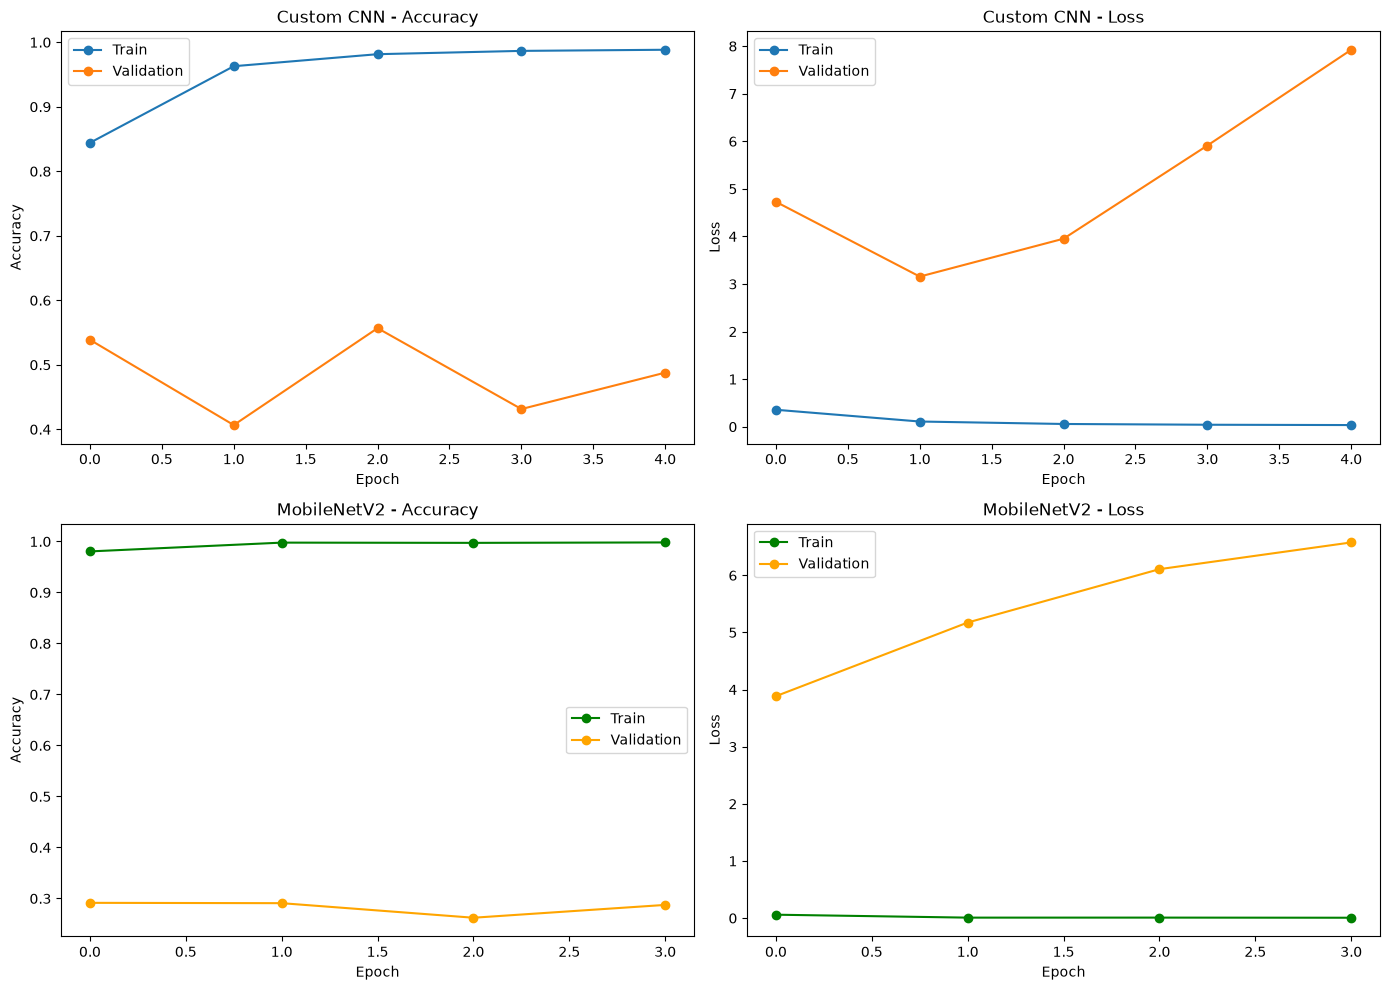

In [23]:
from evaluation import plot_training_curves

plot_training_curves(custom_cnn_history, mobilenetv2_history)

### Interpretation

> * The plots make the divergence pattern from the raw training results visually explicit: for both models, training accuracy rises rapidly toward ~99% while training loss approaches zero, but validation performance remains substantially lower. For the custom CNN, validation accuracy fluctuates considerably while validation loss initially improves and then increases sharply. For MobileNetV2, validation accuracy remains very low from the first epoch onward, while validation loss generally increases. This large and persistent gap between training and validation performance is consistent with strong overfitting and poor generalization to the unseen validation subjects.
> * The custom CNN's validation accuracy curve is notably erratic (0.54 -> 0.41 -> 0.56 -> 0.43 -> 0.49) rather than smoothly declining. This indicates that performance on the held-out validation subjects is unstable across epochs rather than deteriorating in a simple, predictable pattern. The relatively small number of validation subjects (11) may contribute to this variability, although the exact cause cannot be determined from the curves alone.
> * MobileNetV2's validation accuracy curve is comparatively flat and very low (~0.26-0.29) across all four epochs, rather than declining from an initially strong value. This indicates that the model did not achieve useful validation performance even from the first epoch, representing a different failure pattern from the custom CNN. This behavior is consistent with the near-constant Drowsy prediction pattern observed on the test set in Section 8, although the training curves alone cannot establish the exact cause of this behavior.
> * Overall, the curves reinforce the findings from the numerical training results: the custom CNN fits the training data very effectively but struggles to generalize consistently to unseen subjects, while MobileNetV2 shows an even stronger mismatch between training and validation performance. These results support the need to evaluate the models primarily on their performance on unseen subjects rather than on training accuracy alone.

### 7.7 Training Results - Interpretation

> * Both models show strong signs of overfitting: training accuracy rises rapidly to approximately 99% within 4-5 epochs, while validation accuracy remains substantially lower and highly unstable. The custom CNN reaches 98.8% training accuracy by epoch 5, but its validation accuracy fluctuates between 40.7% and 55.7%. MobileNetV2 reaches 99.8% training accuracy by epoch 4, while validation accuracy remains between only 21.6% and 32.3%. This large and persistent train/validation performance gap indicates that both models fit the training subjects much more effectively than they generalize to the unseen validation subjects.
> * Validation loss also shows deterioration after the early epochs. For the custom CNN, validation loss improves from 4.73 to 3.16 between epochs 1 and 2, then increases to 7.92 by epoch 5. For MobileNetV2, validation loss increases from 3.50 at epoch 1 to 4.90 at epoch 3, with a small decrease to 4.40 at epoch 4 that still remains above the initial value. With `EarlyStopping(patience=3)`, training therefore stops after the validation loss fails to improve for three consecutive epochs, and the best weights are restored from epoch 2 for the custom CNN and epoch 1 for MobileNetV2, corresponding to the lowest observed validation loss for each model.
> * The MobileNetV2 validation accuracy is particularly concerning: its 21.6-32.3% range is substantially below both the 50% random-guessing reference and the approximately 53.9% majority-class baseline of the validation set. This indicates that the pretrained feature extractor does not automatically provide useful generalization for this particular subject-level drowsiness task when combined with the current classification head and frozen-base configuration. The custom CNN performs better, but its validation accuracy is still unstable and only marginally exceeds the majority-class baseline at its best observed epoch (55.7%).
> * This behavior is consistent with the possibility that the models are learning subject-specific visual patterns or other recording-related characteristics rather than sufficiently generalizable drowsiness cues. Since `subject_id` perfectly determines `drowsiness_label`, the training subjects provide class-specific visual characteristics that may be easier for the models to exploit than the underlying drowsiness features. The strong training performance combined with poor validation performance on unseen subjects is therefore an important empirical finding, although the exact source of the generalization gap cannot be determined from the training curves alone.
> * The results reinforce the methodological importance of the subject-level split established earlier. An image-level split could have placed images from the same individuals in both training and validation sets, potentially producing much higher validation performance by allowing the models to exploit subject-specific characteristics. The current results instead provide a more realistic indication of the difficulty of generalizing to unseen individuals. Further evaluation on the held-out test subjects in Section 8 will determine whether this generalization problem persists.

***
## 8. Evaluation

Both models are evaluated on the held-out test set (Section 5), using the best weights restored by `EarlyStopping` during training. Evaluation covers:

- **Accuracy** - overall proportion of correct predictions, reported for context but not relied upon alone, given the overfitting observed in Section 7.
- **Confusion matrix** - breaks down predictions into true positives, true negatives, false positives, and false negatives, showing exactly what kinds of mistakes each model makes.
- **Precision, Recall, F1-score** - per-class metrics (defined in the Key Formulas below), giving a fuller picture than accuracy alone, especially relevant here since both models showed unstable validation performance and a mild class imbalance exists in the data.
- **Classification report** - a consolidated summary of precision/recall/F1 for both classes.

Given the overfitting identified in Section 7, test set performance is expected to be similarly poor - this evaluation is not intended to showcase a high-performing model, but to rigorously and honestly quantify how the models actually perform on unseen subjects, which is the central empirical question of this project.

### Key Formulas

* <u>Confusion Matrix Components</u>
1. *Definition* -> a table summarizing prediction outcomes for a binary classifier, breaking predictions into four categories based on the combination of predicted and actual class.
2. *Components*:

    -> **TP** (True Positive): predicted Drowsy, actually Drowsy; <br>
    -> **TN** (True Negative): predicted Non-Drowsy, actually Non-Drowsy; <br>
    -> **FP** (False Positive): predicted Drowsy, actually Non-Drowsy; <br>
    -> **FN** (False Negative): predicted Non-Drowsy, actually Drowsy.

* <u>Accuracy</u>
1. *Definition* -> the proportion of all predictions that were correct. Can be misleading on its own when classes are imbalanced or when a model performs very differently on each class.
2. *Formula*:
$$ Accuracy = \frac{TP + TN}{TP + TN + FP + FN} $$

* <u>Precision</u>
1. *Definition* -> of all the samples the model predicted as Drowsy, the proportion that were actually Drowsy. High precision means few false alarms.
2. *Formula*:
$$ Precision = \frac{TP}{TP + FP} $$

* <u>Recall</u>
1. *Definition* -> of all the samples that were actually Drowsy, the proportion the model correctly identified. High recall means few missed cases - particularly important in a drowsiness detection context, where a missed detection (false negative) could have safety consequences.
2. *Formula*:
$$ Recall = \frac{TP}{TP + FN} $$

* <u>F1-Score</u>
1. *Definition* -> the harmonic mean of precision and recall, giving a single balanced score that penalizes models which sacrifice one metric heavily for the other.
2. *Formula*:
$$ F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} $$

In [18]:
import numpy as np

test_generator.reset()
custom_cnn_probabilities = custom_cnn_model.predict(test_generator)
custom_cnn_predictions = (custom_cnn_probabilities >= 0.5).astype(int).flatten()

test_generator.reset()
mobilenetv2_probabilities = mobilenetv2_model.predict(test_generator)
mobilenetv2_predictions = (mobilenetv2_probabilities >= 0.5).astype(int).flatten()

true_labels = test_generator.classes

print(f"Custom CNN predictions: {len(custom_cnn_predictions)}")
print(f"MobileNetV2 predictions: {len(mobilenetv2_predictions)}")
print(f"True labels: {len(true_labels)}")

199/199 ━━━━━━━━━━━━━━━━━━━━ 167s 840ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 90s 444ms/step
Custom CNN predictions: 6338
MobileNetV2 predictions: 6338
True labels: 6338


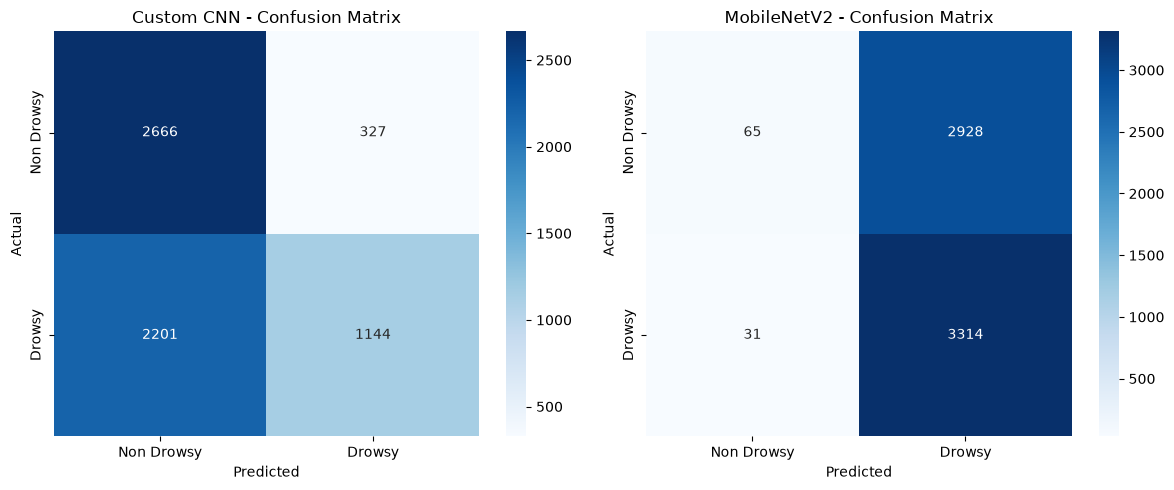

Custom CNN - Classification Report:
              precision    recall  f1-score   support

  Non Drowsy       0.55      0.89      0.68      2993
      Drowsy       0.78      0.34      0.48      3345

    accuracy                           0.60      6338
   macro avg       0.66      0.62      0.58      6338
weighted avg       0.67      0.60      0.57      6338


MobileNetV2 - Classification Report:
              precision    recall  f1-score   support

  Non Drowsy       0.68      0.02      0.04      2993
      Drowsy       0.53      0.99      0.69      3345

    accuracy                           0.53      6338
   macro avg       0.60      0.51      0.37      6338
weighted avg       0.60      0.53      0.38      6338



In [24]:
from evaluation import plot_confusion_matrices, print_classification_reports

plot_confusion_matrices(true_labels, custom_cnn_predictions, mobilenetv2_predictions)
print_classification_reports(true_labels, custom_cnn_predictions, mobilenetv2_predictions)

### Interpretation

> * On the test set, the custom CNN achieves 60% overall accuracy, with asymmetric per-class performance: high recall for Non-Drowsy (0.89) but low recall for Drowsy (0.34), meaning the model misses approximately two-thirds of the actual drowsy samples (2,201 false negatives out of 3,345). For a drowsiness detection application, this is an important limitation because false negatives correspond to drowsy cases that the system fails to detect.
> * MobileNetV2 shows a starkly different failure mode: it predicts "Drowsy" for 6,242 of 6,338 samples (98.5%), resulting in only 0.02 recall for Non-Drowsy and 0.99 recall for Drowsy. Its 53% accuracy is only slightly above the 52.8% majority-class baseline obtained by predicting Drowsy for every test sample. This indicates that the model has largely collapsed toward the majority-class prediction rather than learning a balanced decision boundary between the two classes.
> * Notably, both models perform better on the test set than their validation accuracy during training (custom CNN: 60% test accuracy vs. 40-56% validation accuracy; MobileNetV2: 53% vs. 21-32%). This difference indicates that performance varies substantially across the specific subjects assigned to the validation and test partitions. This is consistent with the subject-confound hypothesis discussed in Section 7.6, although the exact cause of the split-to-split variation cannot be determined from these results alone.
> * Overall, neither model demonstrates reliable and balanced drowsiness detection on unseen individuals. The custom CNN is the stronger of the two models because it distinguishes between the classes to some extent, although its low Drowsy recall (0.34) remains a significant limitation. MobileNetV2, despite its pretrained feature extractor, is heavily biased toward predicting Drowsy under the current configuration and provides little evidence of balanced discrimination between the two classes. These results highlight the difficulty of generalizing from the available subject-level data to previously unseen individuals.